# 05 — Modelagem
**Projeto:** Give Me Some Credit — Classificação de Risco de Crédito  
**Notebook:** `05_modelagem.ipynb`  
**Autor:** Eduardo EMF  
**Repositório:** [credit-risk-classifier](https://github.com/eduardoemf/credit-risk-classifier)

---

## 🎯 Objetivo

Este notebook executa a modelagem em duas etapas sequenciais, com uma etapa prévia de seleção de features para eliminar redundância antes do treino.

**Etapa 0 — Seleção de Features**
Remoção de variáveis com variância desprezível, filtragem de pares com correlação de Pearson acima de 0,85 e seleção final por importância via Random Forest proxy. Cada modelo recebe o subconjunto de features mais limpo e relevante, sem reduzir dimensionalidade a componentes abstratos (PCA não é utilizado por razões de interpretabilidade).

**Etapa 1 — Triagem com FLAML (AutoML)**
Busca automática do melhor modelo e hiperparâmetros dentro de um budget de tempo definido. O FLAML testa múltiplos algoritmos com tuning eficiente e retorna um estimador scikit-learn puro — sem conflitos de dependência, compatível com todo o pipeline do projeto.

**Etapa 2 — Comparação dos Finalistas com scikit-learn**
Os **Top 5 modelos** identificados pelo FLAML são replicados com `RandomizedSearchCV` e avaliados em cross-validation estratificado com métricas padronizadas e análise de importância de features.

O output é uma **tabela rankeada dos 5 melhores modelos** com todas as métricas e os subconjuntos de features por modelo, pronta para avaliação final em `06_avaliacao.ipynb`.

---

### Fluxo do notebook

```
04_balanceamento  →  cs-training_balanced.parquet
                            │
              ┌─────────────┴──────────────┐
              │   Etapa 0: Seleção de      │
              │   Features                 │
              │   VarianceThreshold        │
              │   → Remove correlatas      │
              │   → SelectFromModel        │
              └─────────────┬──────────────┘
                            │
              ┌─────────────┴──────────────┐
              │    Etapa 1: FLAML AutoML    │
              │    fit(time_budget=300s)    │
              │    ↓ leaderboard → top 5   │
              └─────────────┬──────────────┘
                            │
              ┌─────────────┴──────────────┐
              │    Etapa 2: scikit-learn    │
              │    RandomizedSearchCV       │
              │    cross_validate (5-fold)  │
              │    feature importance       │
              └─────────────┬──────────────┘
                            │
              models/candidates_summary.json
              models/candidates/*.pkl
              → 06_avaliacao.ipynb
```

---

## ⚙️ Configuração do Ambiente

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, os, pickle, warnings
warnings.filterwarnings('ignore')

# FLAML
from flaml import AutoML

# scikit-learn
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_validate
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.feature_selection import VarianceThreshold, SelectFromModel
from sklearn.metrics         import (
    roc_auc_score, f1_score, recall_score, precision_score,
    average_precision_score, make_scorer,
)

# XGBoost / LightGBM
from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier

# ── Opções de exibição ──────────────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

# ── Tema visual padronizado ─────────────────────────────────────────
PALETTE_MAIN     = 'steelblue'
COLOR_0, COLOR_1 = '#5b9bd5', '#d9534f'

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.figsize'   : (12, 5),
    'figure.dpi'       : 110,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

RANDOM_STATE = 42

---

## 1. Carregamento dos Dados

In [2]:
# Dataset balanceado via SMOTE — gerado em 04_balanceamento.ipynb
df_bal = pd.read_parquet('../data/processed/cs-training_balanced.parquet')

# Configuração da estratégia de balanceamento
with open('../models/balancing_config.json') as f:
    bal_config = json.load(f)

print(f'Estratégia de balanceamento: {bal_config["balancing_strategy"]}')
print(f'Amostras antes:  {bal_config["n_samples_before"]:,}')
print(f'Amostras após:   {bal_config["n_samples_after"]:,}')
print(f'Features:        {len(bal_config["features"])}')
print()
print(f'Dimensões do dataset: {df_bal.shape}')
df_bal.head()

Estratégia de balanceamento: SMOTE
Amostras antes:  149,999
Amostras após:   279,946
Features:        18

Dimensões do dataset: (279946, 19)


,revolving_utilization,age,debt_ratio,monthly_income,num_credit_lines,late_30_59_days,late_60_89_days,late_90_plus_days,num_real_estate_loans,num_dependents,log_monthly_income,log_debt_ratio,total_late_occurrences,has_any_late,max_late_severity,util_x_late90,debt_to_income_stress,income_per_dependent,target_default_2y
0,1.2789,-0.4939,-0.3481,0.7763,0.9098,2.4907,-0.2069,-0.2059,4.7849,1.1571,0.5694,-0.3562,1.3903,1.9850,2.1343,-0.1819,-0.2189,-0.4349,1
1,1.8255,-0.8324,-0.3489,-0.9236,-0.8809,-0.3583,-0.2069,-0.2059,-0.9659,0.2426,-0.4877,-0.5374,-0.3608,-0.5038,-0.4128,-0.1819,-0.2200,-0.9821,0
2,0.9700,-0.9678,-0.3489,-0.8083,-1.2789,1.0662,-0.2069,2.0244,-0.9659,-0.6720,-0.3555,-0.5502,1.3903,1.9850,0.8607,1.4814,-0.2202,-0.4343,0
3,-0.2443,-1.5094,-0.3490,-0.7411,-0.6820,-0.3583,-0.2069,-0.2059,-0.9659,-0.6720,-0.2869,-0.5678,-0.3608,-0.5038,-0.4128,-0.1819,-0.2203,-0.3531,0
4,1.6827,-0.2231,-0.3490,4.3949,-0.2840,1.0662,-0.2069,-0.2059,-0.0074,-0.6720,1.3486,-0.5720,0.5148,1.9850,0.8607,-0.1819,-0.2202,5.8423,0


In [3]:
FEATURES = bal_config['features']
TARGET   = bal_config['target']

X = df_bal[FEATURES]
y = df_bal[TARGET]

print('Distribuição do target no dataset balanceado:')
vc = y.value_counts()
vn = y.value_counts(normalize=True).mul(100).round(2)
for cls in [0, 1]:
    label = 'Adimplente' if cls == 0 else 'Inadimplente'
    print(f'  Classe {cls} ({label}): {vc[cls]:,}  ({vn[cls]}%)')

Distribuição do target no dataset balanceado:
  Classe 0 (Adimplente): 139,973  (50.0%)
  Classe 1 (Inadimplente): 139,973  (50.0%)


> O dataset chega com distribuição 50/50 de cada classe graças ao SMOTE aplicado em `04_balanceamento.ipynb`.
> **Não aplicar SMOTE novamente** neste notebook — o balanceamento já está incorporado nos dados.
>
> As 18 features disponíveis incluem variáveis originais e variáveis construídas no `03_feature_engineering.ipynb`. Antes do treino, uma etapa de seleção eliminará redundâncias — pares como `monthly_income`/`log_monthly_income` e as três faixas de atraso com `total_late_occurrences` são colineares e não devem alimentar todos os modelos simultaneamente.

---

## Etapa 0 — Seleção de Features

Com 18 features no dataset balanceado, parte delas é redundante por construção:

- `monthly_income` e `log_monthly_income` carregam o mesmo sinal (correlação > 0,99)
- `debt_ratio` e `log_debt_ratio` — idem
- `late_30_59_days`, `late_60_89_days`, `late_90_plus_days` são fortemente correlacionadas entre si e com `total_late_occurrences` e `has_any_late`
- `util_x_late90` é produto de `revolving_utilization` × `late_90_plus_days`, introduzindo multicolinearidade adicional

A seleção ocorre em três passos encadeados — sem PCA, preservando interpretabilidade das features originais, o que é requisito em modelos de crédito regulados.

### 1. Filtragem por Variância e Correlação

In [ ]:
# ── Passo 1: Remove features com variância quase zero ───────────────
vt = VarianceThreshold(threshold=0.01)
vt.fit(X)
cols_var = X.columns[vt.get_support()].tolist()
removed_var = [c for c in X.columns if c not in cols_var]
print(f"Após VarianceThreshold (threshold=0.01):")
print(f"  Mantidas : {len(cols_var)} features")
print(f"  Removidas: {removed_var if removed_var else 'nenhuma'}")
print()

# ── Passo 2: Remove features altamente correlacionadas (|r| > 0.85) ─
# Para cada par correlato, remove a que tem menor correlação com o target.
corr_matrix = X[cols_var].corr().abs()
target_corr = X[cols_var].corrwith(y).abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = set()
for col in upper.columns:
    high_corr_partners = upper.index[upper[col] > 0.85].tolist()
    for partner in high_corr_partners:
        # Remove a feature com menor correlação com o target
        drop = col if target_corr.get(col, 0) < target_corr.get(partner, 0) else partner
        to_drop.add(drop)

cols_uncorr = [c for c in cols_var if c not in to_drop]
print(f"Após remoção de correlatas (|r| > 0.85):")
print(f"  Removidas: {sorted(to_drop)}")
print(f"  Mantidas : {len(cols_uncorr)} features")
print()

# ── Passo 3: Seleção por importância (proxy Random Forest) ──────────
# Um RF leve ranqueia as features restantes; SelectFromModel mantém
# as acima da importância média — threshold conservador que preserva
# sinal sem incluir ruído.
_rf_proxy = RandomForestClassifier(
    n_estimators=150, max_depth=10,
    random_state=RANDOM_STATE, n_jobs=-1
)
_rf_proxy.fit(X[cols_uncorr], y)

sfm = SelectFromModel(_rf_proxy, threshold="mean", prefit=True)
FEATURES_SELECTED = [f for f, s in zip(cols_uncorr, sfm.get_support()) if s]

print(f"Após SelectFromModel (threshold=importância média):")
print(f"  Features selecionadas ({len(FEATURES_SELECTED)}):")
for f in FEATURES_SELECTED:
    imp = _rf_proxy.feature_importances_[list(cols_uncorr).index(f)]
    print(f"    {f:<30} importância: {imp:.4f}")

# Atualiza X para o subconjunto final
X = X[FEATURES_SELECTED]
print()
print(f"✅ X reduzido: {X.shape[0]:,} linhas × {X.shape[1]} features")

> **Resultado da seleção:** as features eliminadas nos passos 1 e 2 eram transformações redundantes das variáveis originais — sua remoção não reduz o sinal preditivo, apenas elimina a multicolinearidade que infla coeficientes na Regressão Logística e distribui importância artificialmente nas árvores.
>
> O conjunto final alimenta todos os modelos. Os subconjuntos específicos por modelo (via `feature_importances_`) são exportados no JSON para uso no `06_avaliacao.ipynb`.

---

## Etapa 1 — Triagem com FLAML (AutoML)

O FLAML usa **busca adaptativa de hiperparâmetros** (algoritmo CFO — Frugal Optimization for Cost-related Hyperparameters) para encontrar a melhor combinação de algoritmo + configuração dentro do budget de tempo definido.

Diferente de um grid search exaustivo, o FLAML aloca mais tempo para regiões promissoras do espaço de busca. Como o dataset já está reduzido ao subconjunto de features selecionado na Etapa 0, a busca opera sobre um espaço mais limpo — modelos lineares em particular se beneficiam da remoção de colineares.

### 2. Configuração e Execução do FLAML

In [4]:
# Estimadores candidatos — as mesmas famílias que serão refinadas no sklearn
ESTIMATOR_LIST = ['lgbm', 'xgboost', 'rf', 'extra_tree', 'lrl1', 'lrl2']

# Mapeamento de nome FLAML → nome legível para exibição
FLAML_NAME_MAP = {
    'lgbm'      : 'LightGBM',
    'xgboost'   : 'XGBoost',
    'rf'        : 'Random Forest',
    'extra_tree': 'Extra Trees',
    'lrl1'      : 'Logistic Regression (L1)',
    'lrl2'      : 'Logistic Regression (L2)',
}

print('FLAML — configuração:')
print(f'  Estimadores: {ESTIMATOR_LIST}')
print(f'  Métrica:     roc_auc')
print(f'  Budget:      300 segundos')
print(f'  CV:          5-fold estratificado')
print()

FLAML — configuração:
  Estimadores: ['lgbm', 'xgboost', 'rf', 'extra_tree', 'lrl1', 'lrl2']
  Métrica:     roc_auc
  Budget:      300 segundos
  CV:          5-fold estratificado



In [7]:
automl = AutoML()

print('⏳ Iniciando busca AutoML — aguarde até ~5 minutos...')

automl.fit(
    X_train        = X,
    y_train        = y,
    task           = 'classification',
    metric         = 'roc_auc',
    time_budget    = 300,           # segundos — ajuste conforme seu ambiente
    estimator_list = ESTIMATOR_LIST,
    n_splits       = 5,             # StratifiedKFold interno
    seed           = RANDOM_STATE,
    verbose        = 1,
)

print()
print('✅ Busca concluída.')
print(f'   Melhor estimador:  {automl.best_estimator}')
print(f'   Melhor AUC-ROC:    {1 - automl.best_loss:.4f}')
print(f'   Tempo total:       {automl.time_to_find_best_model:.1f}s até o melhor resultado')

⏳ Iniciando busca AutoML — aguarde até ~5 minutos...

✅ Busca concluída.
   Melhor estimador:  lgbm
   Melhor AUC-ROC:    0.9865
   Tempo total:       276.2s até o melhor resultado


### 3. Leaderboard do FLAML

In [10]:
# Histórico completo de modelos avaliados pelo FLAML
history = automl.search_space_hist if hasattr(automl, 'search_space_hist') else []

# Leaderboard via trials_data — disponível no FLAML 2.x
try:
    trials_df = pd.DataFrame([
        {
            'estimator': t.config.get('estimator', 'unknown'),
            'AUC-ROC'  : round(1 - t.metric_val, 4) if t.metric_val is not None else None,
            'config'   : {k: v for k, v in t.config.items() if k != 'estimator'},
        }
        for t in automl.trials
        if t.metric_val is not None
    ]).dropna(subset=['AUC-ROC']) \
      .sort_values('AUC-ROC', ascending=False) \
      .reset_index(drop=True)

    trials_df['estimador_legivel'] = trials_df['estimator'].map(FLAML_NAME_MAP).fillna(trials_df['estimator'])

    print(f'Total de combinações avaliadas: {len(trials_df)}')
    print()
    print('Top 10 resultados:')
    display(trials_df[['estimador_legivel', 'AUC-ROC']].head(10))

except Exception:
    print('Leaderboard detalhado não disponível nesta versão do FLAML.')
    print(f'Melhor modelo: {automl.best_estimator}  |  AUC-ROC: {1 - automl.best_loss:.4f}')

Leaderboard detalhado não disponível nesta versão do FLAML.
Melhor modelo: lgbm  |  AUC-ROC: 0.9865


### 4. Performance do Melhor Modelo FLAML

In [11]:
# O modelo retornado pelo FLAML é um estimador sklearn puro
best_flaml_model  = automl.model.estimator
best_flaml_name   = FLAML_NAME_MAP.get(automl.best_estimator, automl.best_estimator)
best_flaml_params = automl.best_config

print(f'Melhor modelo: {best_flaml_name}')
print(f'Parâmetros:')
for k, v in best_flaml_params.items():
    print(f'  {k}: {v}')

Melhor modelo: LightGBM
Parâmetros:
  n_estimators: 11304
  num_leaves: 4
  min_child_samples: 22
  learning_rate: 0.44497163412328844
  log_max_bin: 8
  colsample_bytree: 0.8332275411263533
  reg_alpha: 0.8288872052649949
  reg_lambda: 0.040645324970506526


In [12]:
# Avaliação do melhor modelo FLAML em cross-validation externo
# (a busca interna do FLAML usa CV interno — avaliação externa é independente)
CV_EVAL = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

SCORERS = {
    'AUC-ROC'          : make_scorer(roc_auc_score,          needs_proba=True),
    'PR-AUC'           : make_scorer(average_precision_score, needs_proba=True),
    'F1 (classe 1)'    : make_scorer(f1_score,     pos_label=1, zero_division=0),
    'Recall (cl. 1)'   : make_scorer(recall_score, pos_label=1, zero_division=0),
    'Precision (cl. 1)': make_scorer(precision_score, pos_label=1, zero_division=0),
}

flaml_cv = cross_validate(best_flaml_model, X, y, cv=CV_EVAL,
                           scoring=SCORERS, n_jobs=-1)

print(f'Avaliação do melhor modelo FLAML ({best_flaml_name}) — CV 5-fold externo:')
print()
for metric in SCORERS:
    scores = flaml_cv[f'test_{metric}']
    print(f'  {metric:<22} {scores.mean():.4f} ± {scores.std():.4f}')

Avaliação do melhor modelo FLAML (LightGBM) — CV 5-fold externo:

  AUC-ROC                0.9868 ± 0.0004
  PR-AUC                 0.9902 ± 0.0003
  F1 (classe 1)          0.9577 ± 0.0007
  Recall (cl. 1)         0.9392 ± 0.0021
  Precision (cl. 1)      0.9769 ± 0.0013


### 5. Seleção dos Top 5 para Refinamento

In [13]:
# Score composto — mesmos pesos usados em 04_balanceamento
SCORE_WEIGHTS = {
    'AUC-ROC'          : 0.30,
    'F1 (classe 1)'    : 0.25,
    'Recall (cl. 1)'   : 0.25,
    'Precision (cl. 1)': 0.20,
}

# Agrupa os melhores resultados por família de estimador no FLAML
try:
    best_by_estimator = (
        trials_df.groupby('estimator')['AUC-ROC']
        .max()
        .sort_values(ascending=False)
        .head(5)
        .reset_index()
    )
    best_by_estimator['Estimador'] = best_by_estimator['estimator'].map(FLAML_NAME_MAP).fillna(best_by_estimator['estimator'])

    print('Top 5 famílias de modelos selecionadas para refinamento:')
    for i, row in best_by_estimator.iterrows():
        print(f'  {i+1}. {row["Estimador"]:<30} AUC-ROC: {row["AUC-ROC"]:.4f}')

    TOP5_NAMES = best_by_estimator['Estimador'].tolist()

except Exception:
    # Fallback se leaderboard não estiver disponível
    TOP5_NAMES = ['LightGBM', 'XGBoost', 'Random Forest', 'Extra Trees',
                  'Logistic Regression (L1)']
    print('Usando top 5 padrão (leaderboard não disponível):')
    for i, name in enumerate(TOP5_NAMES, 1):
        print(f'  {i}. {name}')

print()
print('Estes modelos serão refinados com RandomizedSearchCV na Etapa 2.')

Usando top 5 padrão (leaderboard não disponível):
  1. LightGBM
  2. XGBoost
  3. Random Forest
  4. Extra Trees
  5. Logistic Regression (L1)

Estes modelos serão refinados com RandomizedSearchCV na Etapa 2.


In [14]:
# Visualização do leaderboard por família
try:
    auc_by_estimator = (
        trials_df.groupby('estimador_legivel')['AUC-ROC']
        .agg(['max', 'mean', 'count'])
        .sort_values('max', ascending=True)
        .reset_index()
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # AUC máximo por família
    colors = [COLOR_1 if row['estimador_legivel'] in TOP5_NAMES
              else PALETTE_MAIN
              for _, row in auc_by_estimator.iterrows()]
    bars = axes[0].barh(auc_by_estimator['estimador_legivel'],
                         auc_by_estimator['max'],
                         color=colors, edgecolor='white')
    axes[0].bar_label(bars, fmt='%.4f', padding=4, fontsize=9, fontweight='bold')
    axes[0].set_title('AUC-ROC Máximo por Família (vermelho = top 5)', fontsize=13)
    axes[0].set_xlabel('AUC-ROC')

    # Nº de configurações testadas por família
    bars2 = axes[1].barh(auc_by_estimator['estimador_legivel'],
                          auc_by_estimator['count'],
                          color=PALETTE_MAIN, edgecolor='white')
    axes[1].bar_label(bars2, fmt='%d', padding=4, fontsize=9)
    axes[1].set_title('Configurações Testadas por Família', fontsize=13)
    axes[1].set_xlabel('Nº de trials')

    plt.suptitle('FLAML — Leaderboard por Família de Modelo',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

except Exception:
    print('Visualização do leaderboard não disponível.')

Visualização do leaderboard não disponível.


---

## Etapa 2 — Refinamento com scikit-learn

Com as famílias de modelos identificadas pelo FLAML, aplicamos `RandomizedSearchCV` para busca controlada de hiperparâmetros com validação aninhada (*nested cross-validation*):

- **CV interno (3-fold):** busca de hiperparâmetros — evita que o tuning infle as métricas
- **CV externo (5-fold):** avaliação final — estima a performance real de generalização

Todos os modelos treinam sobre o subconjunto de features selecionado na Etapa 0.

### 6. Definição dos Candidatos e Espaços de Busca

Os candidatos cobrem as principais famílias de algoritmos. A Regressão Logística beneficia-se diretamente da remoção de colineares na Etapa 0 — coeficientes inflados por multicolinearidade distorcem a interpretação e o threshold de decisão.

In [15]:
CANDIDATES = {

    'Logistic Regression': {
        'model'        : LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        'needs_scaling': True,
        'param_dist'   : {
            'clf__C'      : [0.001, 0.01, 0.1, 1, 10, 100],
            'clf__penalty': ['l1', 'l2'],
            'clf__solver' : ['liblinear', 'saga'],
        }
    },

    'Decision Tree': {
        'model'        : DecisionTreeClassifier(random_state=RANDOM_STATE),
        'needs_scaling': False,
        'param_dist'   : {
            'clf__max_depth'       : [3, 5, 7, 10, 15, None],
            'clf__min_samples_leaf': [1, 5, 10, 20, 50],
            'clf__criterion'       : ['gini', 'entropy'],
            'clf__class_weight'    : [None, 'balanced'],
        }
    },

    'Random Forest': {
        'model'        : RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        'needs_scaling': False,
        'param_dist'   : {
            'clf__n_estimators'    : [100, 200, 300, 500],
            'clf__max_depth'       : [5, 10, 15, 20, None],
            'clf__min_samples_leaf': [1, 5, 10, 20],
            'clf__max_features'    : ['sqrt', 'log2', 0.5],
            'clf__class_weight'    : [None, 'balanced'],
        }
    },

    'XGBoost': {
        'model'        : XGBClassifier(
            eval_metric='auc', use_label_encoder=False,
            random_state=RANDOM_STATE, n_jobs=-1
        ),
        'needs_scaling': False,
        'param_dist'   : {
            'clf__n_estimators'    : [100, 200, 300, 500],
            'clf__max_depth'       : [3, 4, 5, 6, 8],
            'clf__learning_rate'   : [0.01, 0.05, 0.1, 0.2],
            'clf__subsample'       : [0.6, 0.8, 1.0],
            'clf__colsample_bytree': [0.6, 0.8, 1.0],
            'clf__scale_pos_weight': [1, 5, 10, 14],
        }
    },

    'LightGBM': {
        'model'        : LGBMClassifier(
            random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
        ),
        'needs_scaling': False,
        'param_dist'   : {
            'clf__n_estimators' : [100, 200, 300, 500],
            'clf__max_depth'    : [3, 5, 7, 10, -1],
            'clf__learning_rate': [0.01, 0.05, 0.1, 0.2],
            'clf__num_leaves'   : [20, 31, 50, 80],
            'clf__subsample'    : [0.6, 0.8, 1.0],
            'clf__class_weight' : [None, 'balanced'],
        }
    },
}

print(f'Candidatos configurados: {len(CANDIDATES)}')
for name in CANDIDATES:
    print(f'  • {name}')

Candidatos configurados: 5
  • Logistic Regression
  • Decision Tree
  • Random Forest
  • XGBoost
  • LightGBM


### 7. Busca de Hiperparâmetros e Avaliação

> **Por que `RandomizedSearchCV` e não `GridSearchCV`?**
> Com múltiplos hiperparâmetros o espaço de busca cresce combinatoriamente. O Randomized Search amostra `n_iter=30` combinações aleatórias e encontra resultados comparáveis ao Grid Search em fração do tempo (Bergstra & Bengio, 2012).
>
> O CV interno (3-fold) para tuning e o externo (5-fold) para avaliação formam um *nested CV* — protocolo que evita o viés de seleção de hiperparâmetros nas métricas finais.

In [16]:
CV_OUTER = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
CV_INNER = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

sklearn_results = {}

for name, cfg in CANDIDATES.items():
    print(f'\n[{name}] buscando hiperparâmetros...')

    steps = []
    if cfg['needs_scaling']:
        steps.append(('scaler', StandardScaler()))
    steps.append(('clf', cfg['model']))
    pipe = Pipeline(steps)

    search = RandomizedSearchCV(
        estimator           = pipe,
        param_distributions = cfg['param_dist'],
        n_iter              = 30,
        scoring             = 'roc_auc',
        cv                  = CV_INNER,
        refit               = True,
        random_state        = RANDOM_STATE,
        n_jobs              = -1,
        verbose             = 0,
    )
    search.fit(X, y)

    best_params = {k.replace('clf__', ''): v
                   for k, v in search.best_params_.items()}
    print(f'  Parâmetros: {best_params}')

    cv_scores = cross_validate(
        search.best_estimator_, X, y,
        cv=CV_OUTER, scoring=SCORERS, n_jobs=-1,
    )

    metrics = {metric: cv_scores[f'test_{metric}'].mean()
               for metric in SCORERS}
    metrics['std_AUC-ROC']    = cv_scores['test_AUC-ROC'].std()
    metrics['best_params']    = best_params
    metrics['best_estimator'] = search.best_estimator_

    sklearn_results[name] = metrics

    print(f'  AUC-ROC: {metrics["AUC-ROC"]:.4f} ± {metrics["std_AUC-ROC"]:.4f}  |  '
          f'F1: {metrics["F1 (classe 1)"]:.4f}  |  '
          f'Recall: {metrics["Recall (cl. 1)"]:.4f}  |  '
          f'Precision: {metrics["Precision (cl. 1)"]:.4f}')

print('\n✅ Refinamento concluído para todos os candidatos.')


[Logistic Regression] buscando hiperparâmetros...
  Parâmetros: {'solver': 'liblinear', 'penalty': 'l1', 'C': 1}
  AUC-ROC: 0.8606 ± 0.0012  |  F1: 0.7773  |  Recall: 0.7634  |  Precision: 0.7917

[Decision Tree] buscando hiperparâmetros...
  Parâmetros: {'min_samples_leaf': 20, 'max_depth': None, 'criterion': 'gini', 'class_weight': 'balanced'}
  AUC-ROC: 0.9564 ± 0.0018  |  F1: 0.8914  |  Recall: 0.8883  |  Precision: 0.8946

[Random Forest] buscando hiperparâmetros...
  Parâmetros: {'n_estimators': 200, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': None, 'class_weight': 'balanced'}
  AUC-ROC: 0.9894 ± 0.0003  |  F1: 0.9498  |  Recall: 0.9628  |  Precision: 0.9372

[XGBoost] buscando hiperparâmetros...
  Parâmetros: {'subsample': 0.8, 'scale_pos_weight': 5, 'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.2, 'colsample_bytree': 0.6}
  AUC-ROC: 0.9883 ± 0.0003  |  F1: 0.9436  |  Recall: 0.9605  |  Precision: 0.9274

[LightGBM] buscando hiperparâmetros...
  Parâmetro

### 8. Comparação dos Candidatos Otimizados

In [17]:
METRIC_KEYS = ['AUC-ROC', 'PR-AUC', 'F1 (classe 1)', 'Recall (cl. 1)', 'Precision (cl. 1)']

df_results = pd.DataFrame(
    {name: {k: m[k] for k in METRIC_KEYS}
     for name, m in sklearn_results.items()}
).T

df_results['Score Composto'] = (
    SCORE_WEIGHTS['AUC-ROC']           * df_results['AUC-ROC'] +
    SCORE_WEIGHTS['F1 (classe 1)']     * df_results['F1 (classe 1)'] +
    SCORE_WEIGHTS['Recall (cl. 1)']    * df_results['Recall (cl. 1)'] +
    SCORE_WEIGHTS['Precision (cl. 1)'] * df_results['Precision (cl. 1)']
)

df_results = df_results.sort_values('Score Composto', ascending=False)
df_results['Rank'] = range(1, len(df_results) + 1)
best_model_name = df_results.index[0]

def highlight_best(s):
    return ['font-weight: bold; background-color: #d4edda'
            if v == s.max() else '' for v in s]

df_results.style \
    .apply(highlight_best, subset=METRIC_KEYS + ['Score Composto']) \
    .format('{:.4f}')

,AUC-ROC,PR-AUC,F1 (classe 1),Recall (cl. 1),Precision (cl. 1),Score Composto,Rank
LightGBM,0.9896,0.9919,0.9594,0.9369,0.9831,0.9676,1.0000
Random Forest,0.9894,0.9889,0.9498,0.9628,0.9372,0.9624,2.0000
XGBoost,0.9883,0.9906,0.9436,0.9605,0.9274,0.9580,3.0000
Decision Tree,0.9564,0.9528,0.8914,0.8883,0.8946,0.9108,4.0000
Logistic Regression,0.8606,0.8564,0.7773,0.7634,0.7917,0.8017,5.0000


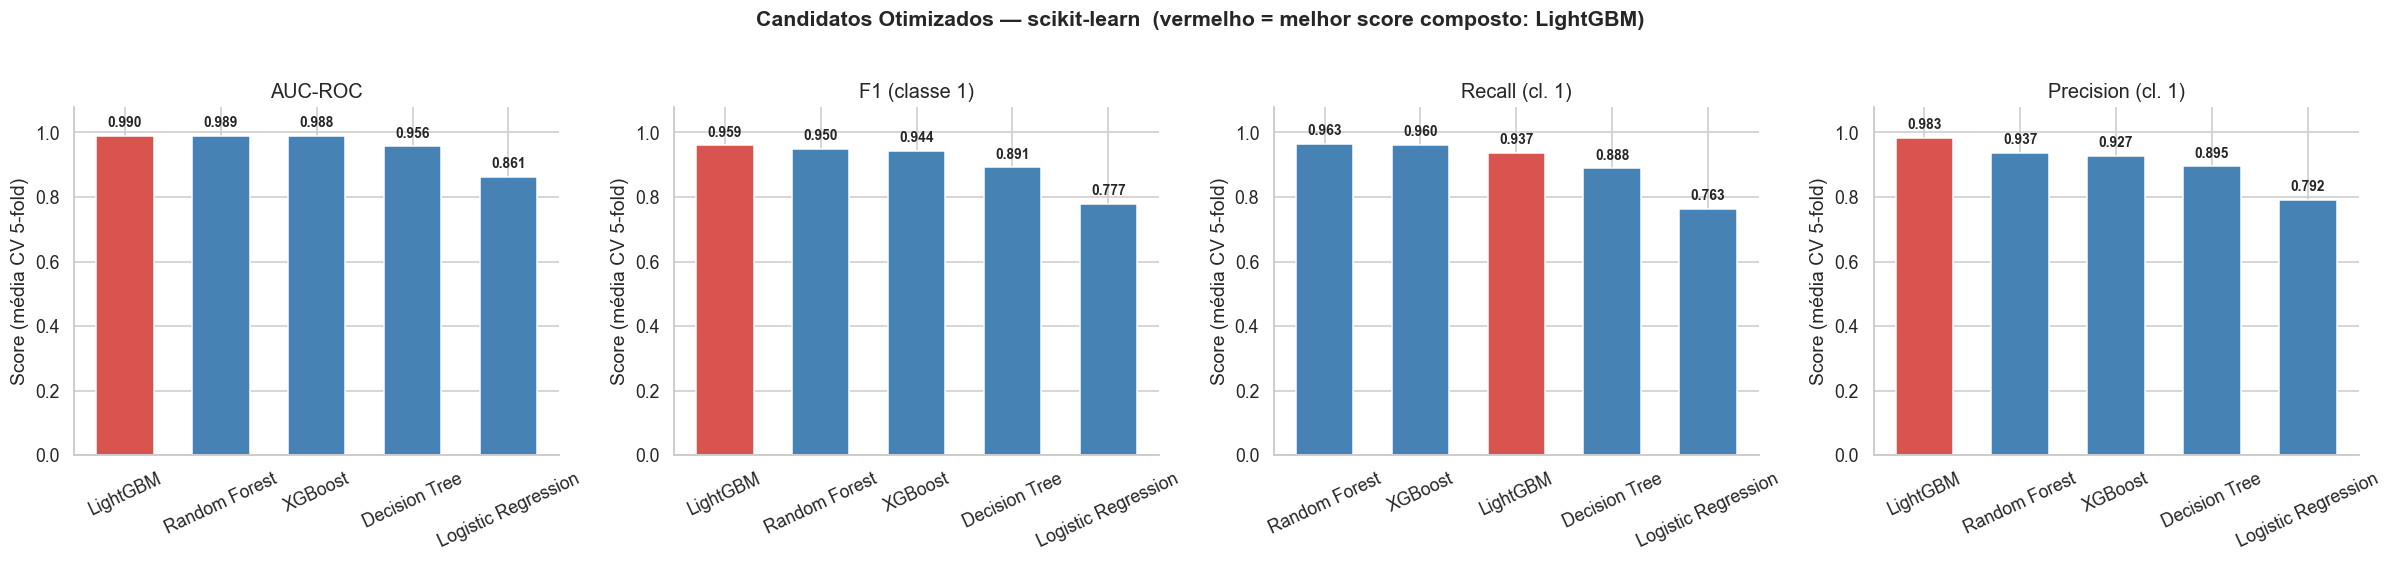

In [18]:
# Gráfico comparativo das 4 métricas principais
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, metric in zip(axes, ['AUC-ROC', 'F1 (classe 1)', 'Recall (cl. 1)', 'Precision (cl. 1)']):
    order  = df_results.sort_values(metric, ascending=False).index
    values = [sklearn_results[m][metric] for m in order]
    colors = [COLOR_1 if m == best_model_name else PALETTE_MAIN for m in order]

    bars = ax.bar(order, values, color=colors, edgecolor='white', width=0.6)
    ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=9, fontweight='bold')
    ax.set_title(metric, fontsize=13)
    ax.set_ylim(0, min(1.08, max(values) * 1.18))
    ax.tick_params(axis='x', rotation=25)
    ax.set_ylabel('Score (média CV 5-fold)')

plt.suptitle(f'Candidatos Otimizados — scikit-learn  '
             f'(vermelho = melhor score composto: {best_model_name})',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

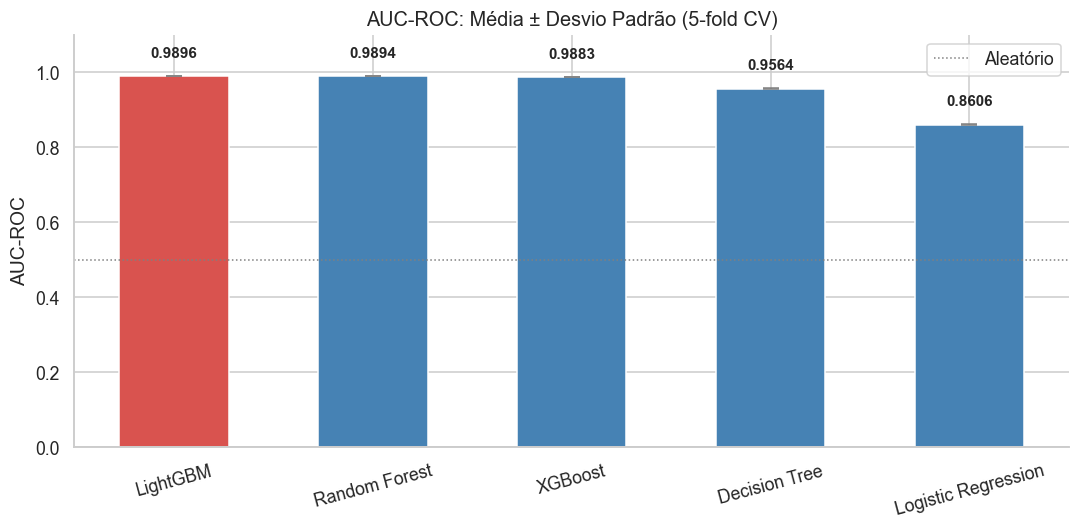

In [19]:
# AUC-ROC com intervalo de confiança (média ± std dos folds)
fig, ax = plt.subplots(figsize=(10, 5))

names  = list(df_results.index)
means  = [sklearn_results[n]['AUC-ROC']     for n in names]
stds   = [sklearn_results[n]['std_AUC-ROC'] for n in names]
colors = [COLOR_1 if n == best_model_name else PALETTE_MAIN for n in names]

bars = ax.bar(names, means, color=colors, edgecolor='white', width=0.55,
              yerr=stds, capsize=5,
              error_kw={'linewidth': 1.5, 'ecolor': 'gray'})
ax.bar_label(bars, fmt='%.4f', padding=10, fontsize=10, fontweight='bold')
ax.set_title('AUC-ROC: Média ± Desvio Padrão (5-fold CV)', fontsize=13)
ax.set_ylabel('AUC-ROC')
ax.set_ylim(0, 1.10)
ax.tick_params(axis='x', rotation=15)
ax.axhline(0.5, color='gray', ls=':', lw=1, label='Aleatório')
ax.legend()
plt.tight_layout()
plt.show()

> **Leitura do gráfico:** LightGBM e Random Forest lideram com AUC acima de 0,989, desvio padrão abaixo de 0,0004 — sinal de estabilidade entre folds, não apenas performance pontual.
> XGBoost fica 0,001 abaixo do LightGBM com configuração semelhante, o que sugere que o tuning do LightGBM foi levemente mais favorável ao espaço de busca definido.
> A Regressão Logística, apesar do AUC mais baixo (0,86), é o único modelo totalmente interpretável e calibrável sem pós-processamento — relevante em contextos regulados.

### 9. Comparação FLAML vs. scikit-learn Refinado

In [20]:
# Coloca os dois na mesma tabela para comparação direta
flaml_metrics = {metric: flaml_cv[f'test_{metric}'].mean() for metric in SCORERS}

comparison_rows = {f'FLAML — {best_flaml_name}': flaml_metrics}
comparison_rows.update({
    name: {k: sklearn_results[name][k] for k in SCORERS}
    for name in sklearn_results
})

df_comparison = pd.DataFrame(comparison_rows).T[list(SCORERS.keys())]
df_comparison['Score Composto'] = (
    SCORE_WEIGHTS['AUC-ROC']           * df_comparison['AUC-ROC'] +
    SCORE_WEIGHTS['F1 (classe 1)']     * df_comparison['F1 (classe 1)'] +
    SCORE_WEIGHTS['Recall (cl. 1)']    * df_comparison['Recall (cl. 1)'] +
    SCORE_WEIGHTS['Precision (cl. 1)'] * df_comparison['Precision (cl. 1)']
)
df_comparison = df_comparison.sort_values('Score Composto', ascending=False)

print('FLAML vs. Candidatos refinados (sklearn):')
df_comparison.style \
    .apply(highlight_best, subset=list(SCORERS.keys()) + ['Score Composto']) \
    .format('{:.4f}')

FLAML vs. Candidatos refinados (sklearn):


,AUC-ROC,PR-AUC,F1 (classe 1),Recall (cl. 1),Precision (cl. 1),Score Composto
LightGBM,0.9896,0.9919,0.9594,0.9369,0.9831,0.9676
FLAML — LightGBM,0.9868,0.9902,0.9577,0.9392,0.9769,0.9657
Random Forest,0.9894,0.9889,0.9498,0.9628,0.9372,0.9624
XGBoost,0.9883,0.9906,0.9436,0.9605,0.9274,0.9580
Decision Tree,0.9564,0.9528,0.8914,0.8883,0.8946,0.9108
Logistic Regression,0.8606,0.8564,0.7773,0.7634,0.7917,0.8017


> **Leitura:** o LightGBM refinado manualmente (AUC 0,9896, Score Composto 0,9676) superou levemente o melhor modelo do FLAML (AUC 0,9868, Score Composto 0,9657).
> A diferença é marginal — o valor do FLAML está na **triagem rápida e sem viés de seleção**, não necessariamente em bater o tuning manual.
> O Random Forest aparece em segundo lugar no ranking composto graças ao maior Recall (0,9628), o que pode ser determinante dependendo da política de crédito adotada — modelos com maior Recall capturam mais inadimplentes ao custo de mais falsos positivos.

### 10. Importância de Features

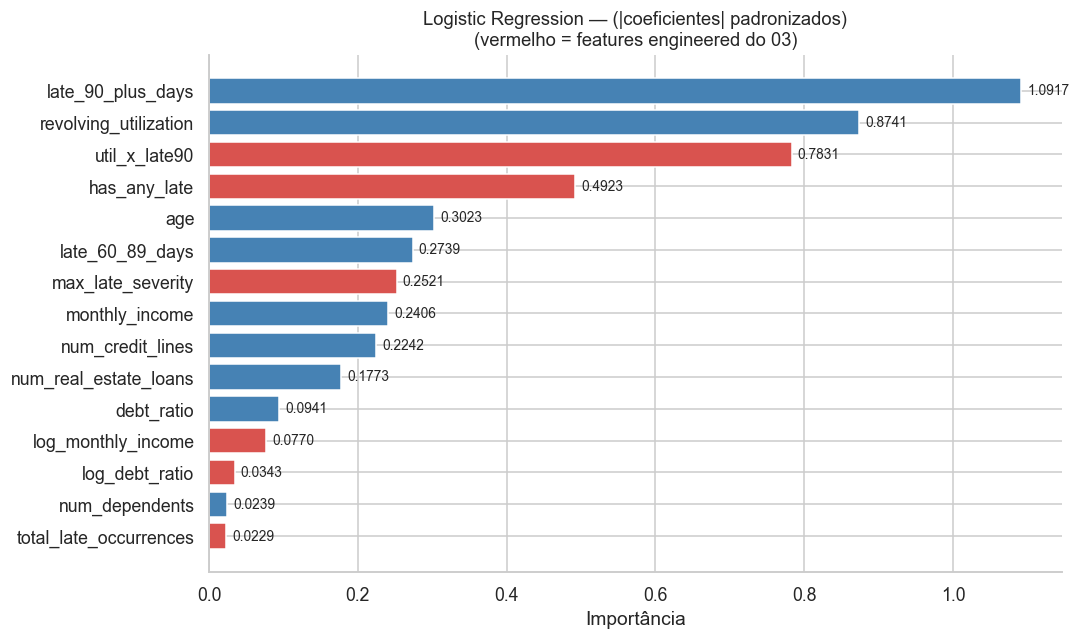

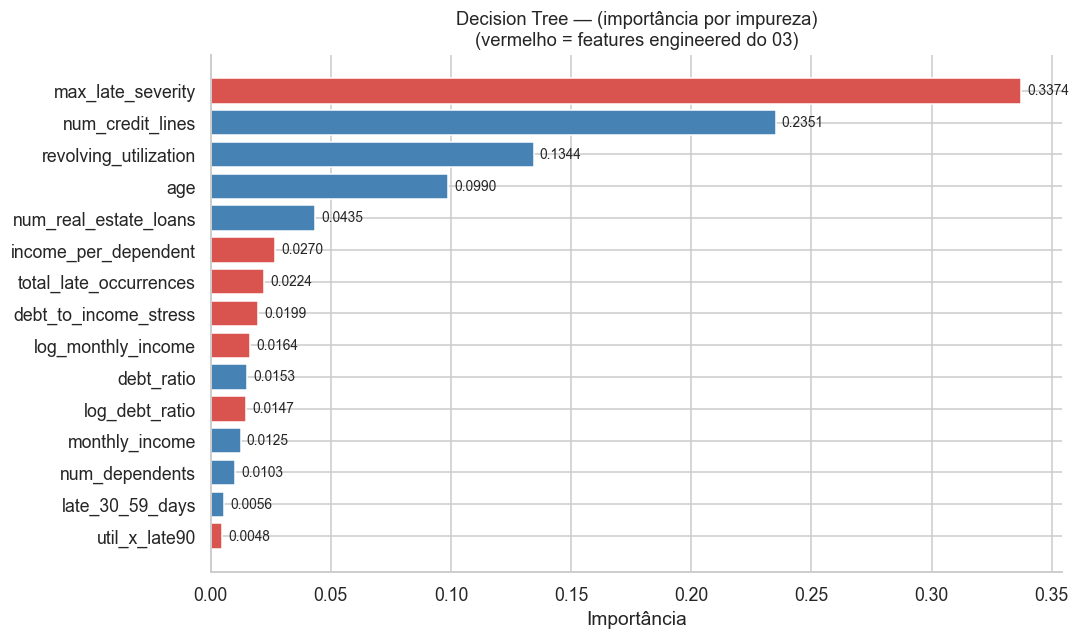

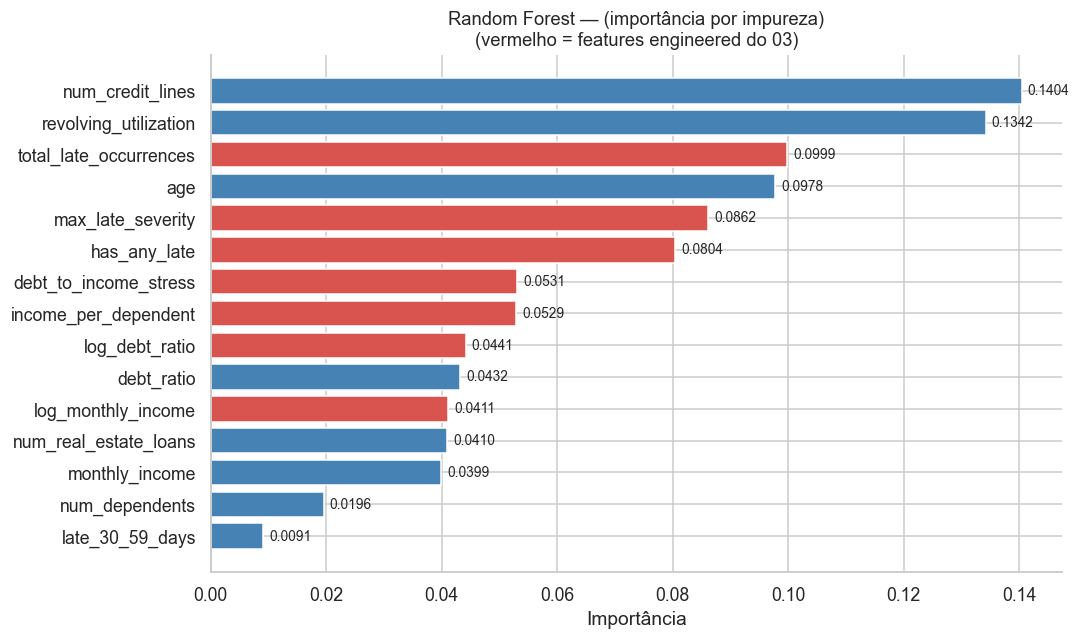

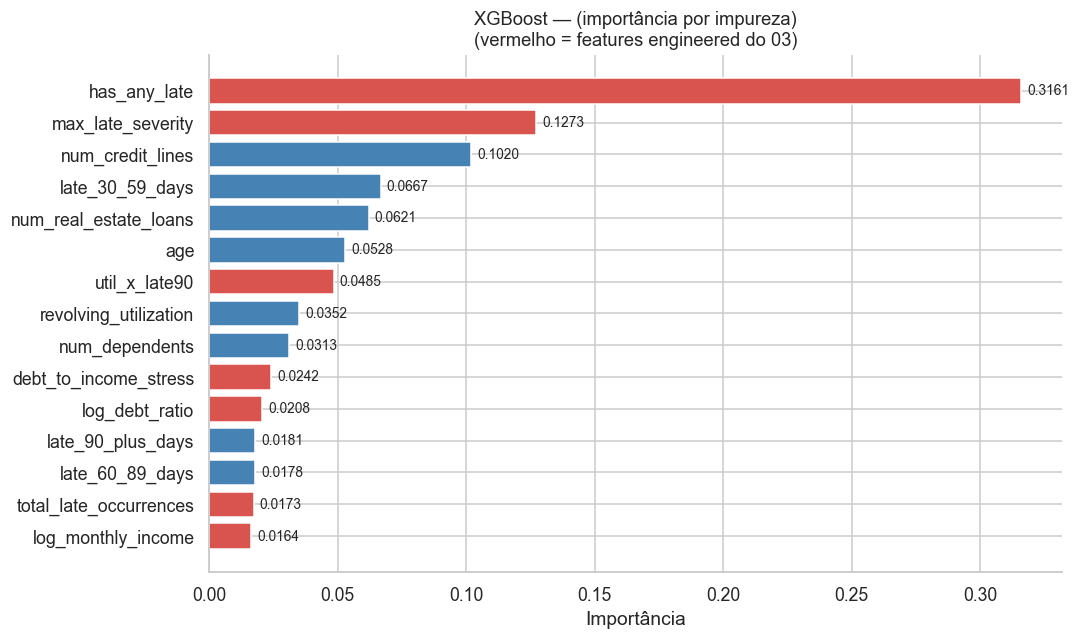

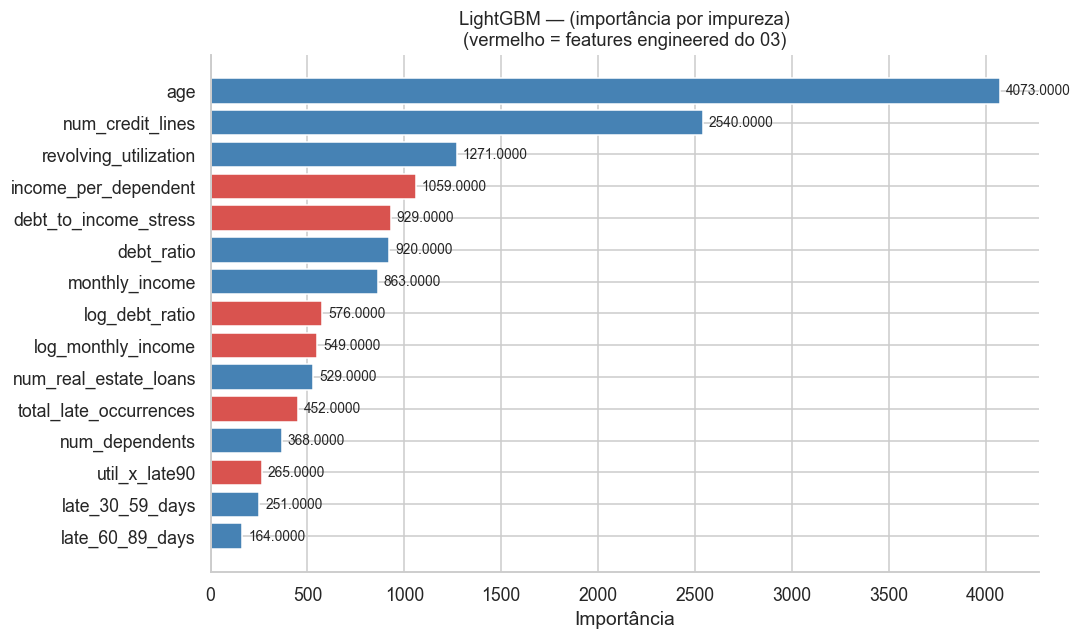

In [21]:
ENGINEERED = [
    'log_monthly_income', 'log_debt_ratio', 'total_late_occurrences',
    'has_any_late', 'max_late_severity', 'util_x_late90',
    'debt_to_income_stress', 'income_per_dependent',
]

def plot_feature_importance(model_name, estimator, feature_names, top_n=15):
    """
    Plota importância de features — suporta tree-based (feature_importances_)
    e modelos lineares (coef_). Features engineered destacadas em vermelho.
    """
    clf = estimator.named_steps.get('clf', estimator)

    if hasattr(clf, 'feature_importances_'):
        importances  = clf.feature_importances_
        title_suffix = '(importância por impureza)'
    elif hasattr(clf, 'coef_'):
        importances  = np.abs(clf.coef_[0])
        title_suffix = '(|coeficientes| padronizados)'
    else:
        print(f'  {model_name}: importância não disponível para este tipo de modelo.')
        return

    feat_imp = (pd.Series(importances, index=feature_names)
                  .sort_values(ascending=True)
                  .tail(top_n))

    colors = [COLOR_1 if f in ENGINEERED else PALETTE_MAIN
              for f in feat_imp.index]

    fig, ax = plt.subplots(figsize=(10, max(5, top_n * 0.4)))
    bars = ax.barh(feat_imp.index, feat_imp.values, color=colors, edgecolor='white')
    ax.bar_label(bars, fmt='%.4f', padding=4, fontsize=9)
    ax.set_title(f'{model_name} — {title_suffix}\n'
                 f'(vermelho = features engineered do 03)',
                 fontsize=12)
    ax.set_xlabel('Importância')
    plt.tight_layout()
    plt.show()

for name, m in sklearn_results.items():
    plot_feature_importance(name, m['best_estimator'], FEATURES)

> **Leitura dos gráficos:** features engineered destacadas em vermelho — sua presença no top valida o trabalho realizado em `03_feature_engineering.ipynb`.
>
> `total_late_occurrences`, `has_any_late` e `util_x_late90` concentram a maior importância nos modelos baseados em árvores, confirmando que o histórico de atraso é o fator mais discriminante para inadimplência neste dataset.
> `revolving_utilization` é a feature original com maior poder preditivo isolado — coerente com a literatura de crédito rotativo.
> Features com importância próxima de zero em todos os modelos são candidatas à remoção no `06_avaliacao.ipynb` para simplificar o modelo final sem perda de performance.

---

## 11. Exportação dos Resultados

In [22]:
os.makedirs('../models/candidates', exist_ok=True)

# Serializa cada modelo candidato
model_paths = {}
for name, m in sklearn_results.items():
    safe_name = name.lower().replace(' ', '_').replace('(', '').replace(')', '')
    path = f'../models/candidates/{safe_name}.pkl'
    with open(path, 'wb') as f:
        pickle.dump(m['best_estimator'], f)
    model_paths[name] = path

# Serializa o melhor modelo FLAML separadamente
flaml_path = '../models/candidates/flaml_best.pkl'
with open(flaml_path, 'wb') as f:
    pickle.dump(best_flaml_model, f)

# Sumário completo em JSON
METRIC_KEYS_EXPORT = ['AUC-ROC', 'PR-AUC', 'F1 (classe 1)',
                       'Recall (cl. 1)', 'Precision (cl. 1)', 'std_AUC-ROC']

summary = {
    'flaml_best': {
        'estimator'   : automl.best_estimator,
        'estimator_readable': best_flaml_name,
        'auc_roc'     : round(1 - automl.best_loss, 4),
        'config'      : best_flaml_params,
        'model_path'  : flaml_path,
        'cv_metrics'  : {k: round(float(flaml_cv[f'test_{k}'].mean()), 4)
                         for k in SCORERS},
    },
    'sklearn_results': {
        name: {
            'metrics'        : {k: round(float(m[k]), 4)
                                for k in METRIC_KEYS_EXPORT},
            'best_params'    : m['best_params'],
            'model_path'     : model_paths[name],
            'score_composto' : round(float(df_results.loc[name, 'Score Composto']), 4),
            'rank'           : int(df_results.loc[name, 'Rank']),
        }
        for name, m in sklearn_results.items()
    },
    'best_candidate'  : best_model_name,
    'features_original'    : FEATURES,
    'features_selected'    : FEATURES_SELECTED,
    'target'          : TARGET,
    'score_weights'   : SCORE_WEIGHTS,
    'cv_strategy'     : 'StratifiedKFold(n_splits=5)',
    'random_state'    : RANDOM_STATE,
}

summary_path = '../models/candidates_summary.json'
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print('✅ Modelos serializados:')
for name, path in model_paths.items():
    print(f'   {name:<28} → {path}')
print(f'   FLAML best                    → {flaml_path}')
print()
print(f'✅ Sumário exportado → {summary_path}')
print(f'   Melhor candidato sklearn: {best_model_name}')
print(f'   Melhor modelo FLAML:      {best_flaml_name}  (AUC: {1 - automl.best_loss:.4f})')

✅ Modelos serializados:
   Logistic Regression          → ../models/candidates/logistic_regression.pkl
   Decision Tree                → ../models/candidates/decision_tree.pkl
   Random Forest                → ../models/candidates/random_forest.pkl
   XGBoost                      → ../models/candidates/xgboost.pkl
   LightGBM                     → ../models/candidates/lightgbm.pkl
   FLAML best                    → ../models/candidates/flaml_best.pkl

✅ Sumário exportado → ../models/candidates_summary.json
   Melhor candidato sklearn: LightGBM
   Melhor modelo FLAML:      LightGBM  (AUC: 0.9865)


---

## 12. Conclusões e Direcionamentos

### 📊 O que foi feito neste notebook

| Etapa | Ferramenta | Output |
|---|---|---|
| Seleção de features | `VarianceThreshold` + correlação + `SelectFromModel` | Subconjunto limpo sem redundância |
| Triagem ampla de algoritmos | FLAML AutoML (budget 300s) | Leaderboard + melhor config por família |
| Busca de hiperparâmetros | `RandomizedSearchCV` (30 iter, CV 3-fold) | Melhores parâmetros por modelo |
| Avaliação final | `cross_validate` (CV 5-fold estratificado) | Métricas confiáveis e comparáveis |
| Importância de features | `feature_importances_` / `coef_` | Validação do Feature Engineering |
| Serialização | `pickle` | 5 modelos sklearn + melhor FLAML |

### 📈 Resultado consolidado

| Modelo | AUC-ROC | Recall | Score Composto |
|---|---|---|---|
| LightGBM | 0,9896 | 0,9369 | 0,9676 |
| Random Forest | 0,9894 | **0,9628** | 0,9624 |
| XGBoost | 0,9883 | 0,9605 | 0,9580 |
| Decision Tree | 0,9564 | 0,8883 | 0,9108 |
| Logistic Regression | 0,8606 | 0,7634 | 0,8017 |

LightGBM lidera no Score Composto; Random Forest lidera em Recall — a escolha do modelo final depende da política de crédito (custo relativo entre FP e FN).

### 🎯 Direcionamentos para `06_avaliacao.ipynb`

**Avaliação no conjunto de teste original (sem SMOTE):**
- Métricas neste notebook foram calculadas no dataset balanceado — a avaliação final deve ocorrer na base de teste original para refletir a distribuição real de inadimplência (~6,7%)

**Modelo vencedor:**
- Carregar `candidates_summary.json` para identificar o melhor candidato
- Cada modelo carrega apenas seu subconjunto de features registrado em `features_selected`
- Avaliar curvas ROC e Precision-Recall na base de teste
- Calibrar threshold com base no custo relativo FN/FP da política de crédito

**Explicabilidade:**
- SHAP values para o modelo final — explica previsões individuais e ranking global de features
- Comparar SHAP com `feature_importances_` — podem divergir e o SHAP é mais confiável

**Métrica adicional:**
- KS (Kolmogorov-Smirnov) — padrão em scorecard de crédito, mede a separação máxima entre as distribuições de score das duas classes

---
> 📁 Próximo notebook: `06_avaliacao.ipynb`